# FRAUD DETECTION 

A classic problem in financial environments. We will take a look at classifying transitions into fraud and not fraud using scikit-learn package.

This notebook will be using a synthetic database found on kaggle for educational purposes because we all need practice :-).   
The data can be found here: https://www.kaggle.com/datasets/jayjoshi37/digital-payment-fraud-detection/data

I will break this proces down into the follwoing steps:

1. Data Exploration 
2. Data prepartion and pre-processing (including feature engineering)
3. Modelling 
4. Evaluation and testing 

We have the following fields within our dataset: 

transaction_id - identifier to each transaction.   
user_id - identifier for each user.   
transaction_amount - amount for each transaction.   
transaction_type - how funds were exchanged e.g "payment" or "bank transfer".   
payment_mode - wallet, card, UPI etc.   
device_type - device transaction was made from e.g iOS.   
device_location - location of the device used to make transaction.   
account_age_days - age of the account.     
transaction_hour - time of transaction in 24 hour notation.    
previous_failed_attempts - if there were previous attempts to make fraudulent transactions.   
avg_transaction_amount - avg amount each account usually makes.   
is_international - is the trasnaction international.    
ip_risk_score - a numerical value  that quantifies the likelihood an IP address is involved in malicious activity, such as fraud, spam, or cyberattacks. 
login_attempts_last_24h - number of login attempts to the account in the last 24 hours.   
fraud_label- is the transaction fraud or not.


## Data Exploration 

In [127]:
# First we need to start by acquiring all of our dependecies 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [251]:
#Now we will load our data into our notebook for modelling:
current_dir = Path.cwd()
print(current_dir)              #this directory is 1 level too low in the project structure
parent_dir = current_dir.parent #go up 1 level in the structure 
print(parent_dir)               #now we are in the parent directory that we can now use to naviagte into the dataset 
file_path = parent_dir/ "dataset" / "Digital_Payment_Fraud_Detection_Dataset.csv" 
print(file_path)                #now we are in the correct bracnh of the tree where our dataset is

fraud = pd.read_csv(file_path)  #IT WORKED!!!


/Users/leta/Desktop/Data Science Career/Python/Python Projects/FraudDetection/modelling
/Users/leta/Desktop/Data Science Career/Python/Python Projects/FraudDetection
/Users/leta/Desktop/Data Science Career/Python/Python Projects/FraudDetection/dataset/Digital_Payment_Fraud_Detection_Dataset.csv


In [252]:
fraud.shape #dimensions of the dataframe

(7500, 15)

In [253]:
#Let us take a look into the data we have 
fraud.head()

,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0,T1,U3756,18758.28,Transfer,UPI,Web,Hyderabad,895,14,1,25535.84,0,0.718,4,0
1,T2,U7899,47538.18,Payment,Wallet,iOS,Hyderabad,918,21,0,3955.85,0,0.525,9,0
2,T3,U1765,36613.10,Payment,Card,Android,Chennai,1506,8,4,22727.71,0,0.985,9,0
3,T4,U8850,29952.99,Payment,Wallet,iOS,Chennai,800,1,3,18095.89,0,0.797,2,0
4,T5,U9049,7843.13,Payment,UPI,Web,Delhi,301,4,1,9317.49,1,0.468,1,0


In [254]:
#In this dataset we have mostly numerical variables with a few catgeroical variables.
#Let us look at what fields we have
fraud.keys() #column names of us data


Index(['transaction_id', 'user_id', 'transaction_amount', 'transaction_type',
       'payment_mode', 'device_type', 'device_location', 'account_age_days',
       'transaction_hour', 'previous_failed_attempts',
       'avg_transaction_amount', 'is_international', 'ip_risk_score',
       'login_attempts_last_24h', 'fraud_label'],
      dtype='str')

In [255]:
#What unique labels do we have in the dataset 
fraud.nunique()
# The fields with the highest unique values are the ID fields, transaction amounts, account ages, avgerage transaction amounts, ip risk scores 
# ID fields are just unqiue ientifiers but have no bearing on prediction therefore we will drop these fields especially since they have many unique values.  
# We will plore some more of these fields to see there bearing on the predcitve power of our models using exploratory data analysis and data mining.

transaction_id              7500
user_id                     5106
transaction_amount          7499
transaction_type               3
payment_mode                   4
device_type                    3
device_location                5
account_age_days            1943
transaction_hour              24
previous_failed_attempts       5
avg_transaction_amount      7498
is_international               2
ip_risk_score               1000
login_attempts_last_24h        9
fraud_label                    2
dtype: int64

In [237]:
# Finally let us see of the data is balanced or not 
fraud["fraud_label"].value_counts(normalize=True) #count all fraud labels and get proportion

# Fraud - 6.52% of observations    
#Non fraud - 93.28% of observations 

# Our data is very skewed towards non fraud transactions.
# This will infrom our metric to measure perfomrance (probably balanced accuarcy, recall and precision) 
# as well as how we stratify the data when partitioning into test and train sets. 


fraud_label
0    0.9348
1    0.0652
Name: proportion, dtype: float64

Our variables with categorical information being: transaction_type, payment_mode, device_type and device_location do not have too many unqiue values.  
This infroms what methods we can use to deal with these values for classification models that only use numerical data.  
- A possible solution would be to use dummy variables. 

##  DATA PREPARATION AND PRE-PROCESSING 


In [256]:
# As we have seen above the ID variables have no bearing on the prediction so we will remove them.
fraud = fraud.drop(columns= ["transaction_id", "user_id", "transaction_type", "payment_mode", "device_type"]) #removing ID columns

FEATURE ENGINEERING 
We will now create features that improve the performance of our models based on the EDA we conducted and the insights we gathered. 

In [257]:
#Dummy varaibles 
# Since we want to use scikit-learn binary classification models, the simplest way is to use dummy varibles for non-numeric variables 
df1 = pd.get_dummies( data = fraud,           #what data we want to get dummies variables of 
                     columns = ["device_location", "is_international", ],  #the non-numeric columns we will convert into dummies
                     dtype=int)               #turning dummies from True/ False into binary 1/0. 

df1.head()

,transaction_amount,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,ip_risk_score,login_attempts_last_24h,fraud_label,device_location_Bangalore,device_location_Chennai,device_location_Delhi,device_location_Hyderabad,device_location_Mumbai,is_international_0,is_international_1
0,18758.28,895,14,1,25535.84,0.718,4,0,0,0,0,1,0,1,0
1,47538.18,918,21,0,3955.85,0.525,9,0,0,0,0,1,0,1,0
2,36613.10,1506,8,4,22727.71,0.985,9,0,0,1,0,0,0,1,0
3,29952.99,800,1,3,18095.89,0.797,2,0,0,1,0,0,0,1,0
4,7843.13,301,4,1,9317.49,0.468,1,0,0,0,1,0,0,0,1


In [258]:
# Bucketing by device location 
# We will use buckets to group transactions by location therefore we will make a fraud index by location. 
# Mumbai and Hyderabad 3, Chennai and Bangalore 2, Delhi 1. 

fraud_location = { #creating a dictionary to map locations onto 
    "Mumbai":3,
    "Hyderabad" :3,
    "Chennai" : 2,
    "Bangalore" : 2,
    "Delhi" : 1

}

df1["fraud_bucket_location"] = fraud["device_location"].map(fraud_location)
df1

,transaction_amount,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,ip_risk_score,login_attempts_last_24h,fraud_label,device_location_Bangalore,device_location_Chennai,device_location_Delhi,device_location_Hyderabad,device_location_Mumbai,is_international_0,is_international_1,fraud_bucket_location
0,18758.28,895,14,1,25535.84,0.718,4,0,0,0,0,1,0,1,0,3
1,47538.18,918,21,0,3955.85,0.525,9,0,0,0,0,1,0,1,0,3
2,36613.10,1506,8,4,22727.71,0.985,9,0,0,1,0,0,0,1,0,2
3,29952.99,800,1,3,18095.89,0.797,2,0,0,1,0,0,0,1,0,2
4,7843.13,301,4,1,9317.49,0.468,1,0,0,0,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,3962.99,1917,14,0,24820.55,0.926,9,0,0,0,1,0,0,1,0,1
7496,3675.11,329,0,4,6208.20,0.036,5,0,0,0,0,1,0,1,0,3
7497,42523.37,67,19,1,27344.69,0.149,6,0,0,1,0,0,0,1,0,2
7498,10681.86,282,15,2,26586.50,0.198,2,0,0,0,0,1,0,1,0,3


In [259]:
# Bucketing by IP Risk scores 
# We also discovered via EDA that certain risk scores ( below 0.51 and above 0.86) have higher fraud we will classify each transaction using this fact 

ip_risk = []

for i in range(0,len(fraud)):
    score = fraud["ip_risk_score"].iloc[i]
    if (score < 0.51 or score > 0.86):
        ip_risk.append(1)
    elif ( 0.51 <= score <= 0.86):
        ip_risk.append(0)

df1["ip_risk_bucket"] = ip_risk
df1.head()

,transaction_amount,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,ip_risk_score,login_attempts_last_24h,fraud_label,device_location_Bangalore,device_location_Chennai,device_location_Delhi,device_location_Hyderabad,device_location_Mumbai,is_international_0,is_international_1,fraud_bucket_location,ip_risk_bucket
0,18758.28,895,14,1,25535.84,0.718,4,0,0,0,0,1,0,1,0,3,0
1,47538.18,918,21,0,3955.85,0.525,9,0,0,0,0,1,0,1,0,3,0
2,36613.10,1506,8,4,22727.71,0.985,9,0,0,1,0,0,0,1,0,2,1
3,29952.99,800,1,3,18095.89,0.797,2,0,0,1,0,0,0,1,0,2,0
4,7843.13,301,4,1,9317.49,0.468,1,0,0,0,1,0,0,0,1,1,1


In [260]:
# Bucketing by number of login attempts 
# Our final discovery was that greater thanor equal to  5 attempted logins had a higher prevalnce of fraud than less than 5 

login_number = []

for i in range(0,len(fraud)):
    number = fraud["login_attempts_last_24h"].iloc[i]
    if (number >= 5):
        login_number.append(1)
    elif ( number< 5):
        login_number.append(0)

df1["login_bucket"] = login_number
df1.head()

,transaction_amount,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,ip_risk_score,login_attempts_last_24h,fraud_label,device_location_Bangalore,device_location_Chennai,device_location_Delhi,device_location_Hyderabad,device_location_Mumbai,is_international_0,is_international_1,fraud_bucket_location,ip_risk_bucket,login_bucket
0,18758.28,895,14,1,25535.84,0.718,4,0,0,0,0,1,0,1,0,3,0,0
1,47538.18,918,21,0,3955.85,0.525,9,0,0,0,0,1,0,1,0,3,0,1
2,36613.10,1506,8,4,22727.71,0.985,9,0,0,1,0,0,0,1,0,2,1,1
3,29952.99,800,1,3,18095.89,0.797,2,0,0,1,0,0,0,1,0,2,0,0
4,7843.13,301,4,1,9317.49,0.468,1,0,0,0,1,0,0,0,1,1,1,0


In [261]:
#Bucketing for our account age 


account_age = []

for i in range(0,len(fraud)):
    age = fraud["account_age_days"].iloc[i]
    if ( 1190 <= age <= 1855):
        account_age.append(5)
    elif ( age < 1190 or age >1855 ):
        account_age.append(0)

df1["account_age_bucket"] = account_age
df1.head()

,transaction_amount,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,ip_risk_score,login_attempts_last_24h,fraud_label,device_location_Bangalore,device_location_Chennai,device_location_Delhi,device_location_Hyderabad,device_location_Mumbai,is_international_0,is_international_1,fraud_bucket_location,ip_risk_bucket,login_bucket,account_age_bucket
0,18758.28,895,14,1,25535.84,0.718,4,0,0,0,0,1,0,1,0,3,0,0,0
1,47538.18,918,21,0,3955.85,0.525,9,0,0,0,0,1,0,1,0,3,0,1,0
2,36613.10,1506,8,4,22727.71,0.985,9,0,0,1,0,0,0,1,0,2,1,1,5
3,29952.99,800,1,3,18095.89,0.797,2,0,0,1,0,0,0,1,0,2,0,0,0
4,7843.13,301,4,1,9317.49,0.468,1,0,0,0,1,0,0,0,1,1,1,0,0


In [ ]:
# We want the columns of IP_Risk_bucket, interational_bucket, fraud_bucket_location, attempted_login_buckets 

In [262]:
# Now we will look at the dimensions of the dataframe to see how many more predictors we have added
df1.shape # we have added 11 new columns, not too many 

(7500, 19)

## MODELLING 

In [263]:
# Now we can start modelling our data usinf sklearn.
#First we download dependencies
from sklearn.linear_model import LogisticRegression #this model acts as our basline model for binary classification 

In [264]:
df1.keys()

Index(['transaction_amount', 'account_age_days', 'transaction_hour',
       'previous_failed_attempts', 'avg_transaction_amount', 'ip_risk_score',
       'login_attempts_last_24h', 'fraud_label', 'device_location_Bangalore',
       'device_location_Chennai', 'device_location_Delhi',
       'device_location_Hyderabad', 'device_location_Mumbai',
       'is_international_0', 'is_international_1', 'fraud_bucket_location',
       'ip_risk_bucket', 'login_bucket', 'account_age_bucket'],
      dtype='str')

In [265]:
# Now we will take partition the data into dependent and indepenedt variables. 
x =df1[['transaction_amount', 'account_age_days', 'transaction_hour',
       'previous_failed_attempts', 'avg_transaction_amount', 'ip_risk_score',
       'login_attempts_last_24h', 'fraud_label', 'device_location_Bangalore',
       'device_location_Chennai', 'device_location_Delhi',
       'device_location_Hyderabad', 'device_location_Mumbai',
       'is_international_0', 'is_international_1', 'fraud_bucket_location',
       'ip_risk_bucket', 'login_bucket', 'account_age_bucket']]
y = df1[['fraud_label']]                               #subsetting our predicted variable 

In [266]:
# Partitioning our data 
# The data will be partitioned into tran and test splits at a 70/30% proportion 

from sklearn.model_selection import train_test_split #package to spilt our data 

x_train, x_test, y_train, y_test = train_test_split(x,y,              #our dependent and independent variables to be used
                                                    stratify = y,     #keeping proportion of fraud and not fraud equal in the the train and test sets
                                                    random_state=123, #setting a seed for reproducibility 
                                                    test_size=0.3)    #30% test size


In [267]:
# Now we can fit the data 
logreg = LogisticRegression() #assining our model to a variables we will call later 
logreg.fit(x_train, y_train)  #fit our training data to the model 

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## EVALUATION AND TESTING 
We have trained our model on the train set.   
We can now use the metrics mentined earlier like balanced accuracy, precision and recall to judge our models

**Precision** - of all the positievs identified how many were truly positive?  
**Recall**- of all possible positive instances, how many did the model catch? 

For fraud detection, we value recall as our main metric.   
This is beacuse catching every fraudlent trasaction allows for the least damage to our client base as opposed to flagging a genuine transaction as fraud that can be reversed wuth no harm to the user. 

In [268]:
y_pred_log = logreg.predict(x_test) #making predictios on the train data 


In [269]:
# Importing balanced accuracy
from sklearn.metrics import accuracy_score,balanced_accuracy_score, precision_recall_curve, confusion_matrix,precision_score, recall_score, ConfusionMatrixDisplay #importing all necesarry metrics

In [270]:
accuracy_score(y_test, y_pred_log) #we have a very high accuracy score of 0.935


0.9457777777777778

In [271]:
balanced_accuracy_score(y_test,y_pred_log) #our balaned accuracy score is very lowe at 0.5

0.6388152978737858

In [ ]:
precision_score(y_test,y_pred_log) # precision is 71.1%

0.711864406779661

In [ ]:
recall_score(y_test,y_pred_log) #recall is 28.5%

0.2857142857142857

This indicates that the imbalance in the dataset even after stratifying the data.     
This indicates that our model learned to predict non fraud every time (class 0) to get a high accuracy bot lowe balanced accuracy, precision and recall   
Therefore we need to find another way to ensure we can identify all the positive cases. 
# We can award a greater penalty to predicting a very imbalanced outcome 

In [274]:
logreg2 = LogisticRegression(class_weight= "balanced") #adding penatly to predciting only one class accuractely 


In [275]:
logreg2.fit(x_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [276]:
y_pred2_log = logreg2.predict(x_test) 

In [277]:
balanced_accuracy_score(y_test, y_pred2_log) #Our model still does not have the best balanced accuracy at 0.525

1.0

In [278]:
precision_score(y_test, y_pred2_log) # precision is also very low 0.0714

1.0

In [279]:
recall_score(y_test, y_pred2_log) #however, our recall is much higher therefore, we have caught more our our fraud cases 0.558

1.0

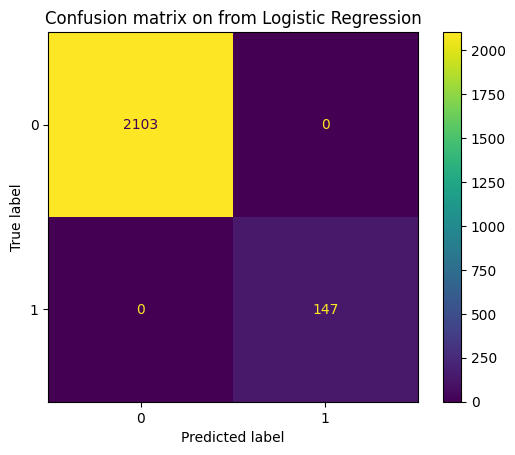

In [280]:
confusion_matrix_log = ConfusionMatrixDisplay.from_predictions( #creating confusion matrix diagram from predictions
    y_test,                                                     #comparing y test data to our predcited values from the logistic regression model
    y_pred2_log
)

plt.title("Confusion matrix on from Logistic Regression")  #setting up the lablels 
plt.show()



In conculsion - even after we add extra penalty to predict each class as good as possible. 
We will now try to use another classification model 

In [ ]:
# Now we will try to use a Random Forest Model 
from sklearn.ensemble import RandomForestClassifier #using a Random Forest model

In [ ]:
random_for = RandomForestClassifier(class_weight= "balanced") #having the penalty between classes being equal

In [ ]:
random_for.fit(x_train, y_train)

In [ ]:
y_pred_rando = random_for.predict(x_test)

In [ ]:
balanced_accuracy_score(y_test, y_pred_rando) #is very low so we cannot catch fraud 

In [ ]:
precision_score(y_test, y_pred_rando) #also very low 0

In [ ]:
recall_score(y_test, y_pred_rando) #low like our logistic regression at 0

In [ ]:
confusion_matrix_rando = ConfusionMatrixDisplay.from_predictions(
    y_test,                #comparing y test data to our predcited values from the random forest model
    y_pred_rando
)
plt.title("Confusiom Matrix of Random Forest")
plt.show()

Both our models minimise error by just predicting not fraud for all the transaction since the data is so skewed in not fraud approximatley 94/6 %.
Therefore since we have such unbalanced data we have to give a much larger penatly to make our models predict both classes more accuractely.   

## MODEL WITH GREATER PENALTY 

In [ ]:
# We will now create both models with a greater penatly for predicting wrong in our fraud class as well as lower our acceptance threshold for fraud.
Log = LogisticRegression(class_weight= "balanced") #a mistake in our fraud class (class 1) is 50 times more detrimental than predicting wrong for class 1
Random = RandomForestClassifier(class_weight= "balanced")

In [ ]:
algos = [Log, Random] #list of our algorithm on training data 
b_accuracy =[]        #empty list of balanced accuracy scores 
recall_metric = []    #empty list of recall  scores  
precision_metric = [] #empty list of precision  scores
threshold = 0.1

for a in algos:  #loop that fits both models and appends balanced accuracy, precsion and recall to the empty lists 
    a.fit(x_train, y_train)
    predictions = (a.predict_proba(x_test)[:,1] >= threshold).astype(int)
    acc = balanced_accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions)
    rec = recall_score(y_test, predictions)
    
    b_accuracy.append(acc)
    recall_metric.append(rec)
    precision_metric.append(prec)


In [ ]:
main_metrics =pd.DataFrame()                                                #create an empty dataframe to add metrics to 
main_metrics["Description"] = [ "Balanced accuracy", "Recall", "Precision"] #create columns of metrc names  
main_metrics["Logistic Regression"] = [b_accuracy[0], recall_metric[0], precision_metric[0]] #add metrics for Logistic regression model
main_metrics["Random Forest"] = [b_accuracy[1], recall_metric[1], precision_metric[1]]       #add metrics for Random forest 


main_metrics

Even after using a lower threshold for classification we still have a very low balanced accuracy for oth models at around 50% as well as a low recal score for Random Forest 22.4% and a high recall for Logistic regression 100%. 

Although the high recall for Logistci Regression may seem good, it does so by over-predicting fraud therefore we trade off our balanced accuracy anf precision. Too many transactions are being flagged as fraud. 

Therefore we can use resampling techniques to solve this issue. 
For severly unbalanced data, there is a resampling technique called SMOTE resampling. 

### SMOTE 
Synthetic Minority Over-Sampling Technique (SMOTE)

SMOTE is a data-level resampling technique that generates synthetic (artificial) samples for the minority class.   
Instead of simply duplicating existing examples, it creates new data points by interpolating between existing ones.   
This approach allows the model to learn broader patterns and reduces the risk of overfitting to repeated samples

In [ ]:
#First let us start by importing the necessary library 
from imblearn.over_sampling import SMOTE 

In [ ]:
# Now we will resample our data 
smote = SMOTE(sampling_strategy="minority", random_state= 40)
x_train_s, y_train_s =  smote.fit_resample(x_train, y_train)

In [ ]:
counts = y_train_s.value_counts() #getting the count of our resampled fraud and non fraud data  points


plt.bar(range(len(counts)),counts.values, color = ['blue','red']) #plotting our resampled data on a bar graph 
plt.xticks([0,1],['Non-fraud','Fraud'])
plt.show()

### Now we will re-run our models on the resampled data

In [ ]:
log_resample = LogisticRegression()
random_resample = RandomForestClassifier()

algos_resample = [log_resample, random_resample] #list of our algorithm on training data 
b_accuracy_resample =[]        #empty list of balanced accuracy scores 
recall_metric_resample = []    #empty list of recall  scores  
precision_metric_resample = [] #empty list of precision  scores

for a in algos_resample:  #loop that fits both models and appends balanced accuracy, precsion and recall to the empty lists 
    a.fit(x_train_s, y_train_s)
    predictions = a.predict(x_test)
    acc = balanced_accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions)
    rec = recall_score(y_test, predictions)
    
    b_accuracy_resample.append(acc)
    recall_metric_resample.append(rec)
    precision_metric_resample.append(prec)

In [ ]:
main_metrics_resample = pd.DataFrame()                                                #create an empty dataframe to add metrics to 
main_metrics_resample["Description"] = [ "Balanced accuracy", "Recall", "Precision"] #create columns of metrc names  
main_metrics_resample["Logistic Regression"] = [b_accuracy_resample[0], recall_metric_resample[0], precision_metric_resample[0]] #add metrics for Logistic regression model
main_metrics_resample["Random Forest"] = [b_accuracy_resample[1], recall_metric_resample[1], precision_metric_resample[1]]       #add metrics for Random forest 


main_metrics_resample